In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D

In [63]:
FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)

np.random.seed(42)

n_train = 200
n_test = 200
d = 20

# True parameters
w_true = np.random.randn(d)

# Training data
X_train = np.random.randn(n_train, d)
noise_train = 0.5 * np.random.randn(n_train)
y_train = X_train @ w_true + noise_train

# Test data
X_test = np.random.randn(n_test, d)
noise_test = 0.5 * np.random.randn(n_test)
y_test = X_test @ w_true + noise_test

In [64]:
def ridge_closed_form(X, y, lam):
    """
    Closed-form Ridge solution w_lambda = (X^T X + lam I)^{-1} X^T y.
    """
    n_features = X.shape[1]
    I = np.eye(n_features)
    A = X.T @ X + lam * I
    b = X.T @ y
    w = np.linalg.solve(A, b)
    return w


def ridge_objective(X, y, w, lam):
    """
    J_lambda(w) = ||Xw - y||_2^2 + lam * ||w||_2^2
    """
    residual = X @ w - y
    data_fit = residual @ residual
    penalty = lam * (w @ w)
    return data_fit + penalty


def ridge_grad(X, y, w, lam):
    """
    Gradient of J_lambda(w): 2 X^T (Xw - y) + 2 lam w
    """
    residual = X @ w - y
    return 2 * (X.T @ residual + lam * w)

def gradient_descent(X, y, lam, s, alpha, beta, max_iter=1000, tol=1e-6):
    """
    Gradient descent with Armijo backtracking.

    Returns:
        w          – final iterate
        obj_vals   – list of objective values per iteration
    """
    w = np.zeros(X.shape[1])
    obj_vals = []

    for it in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        grad_norm_sq = grad @ grad

        f_curr = ridge_objective(X, y, w, lam)
        t = s

        # Armijo backtracking: J(w - t g) <= J(w) - alpha * t * ||g||^2
        while ridge_objective(X, y, w - t * grad, lam) > f_curr - alpha * t * grad_norm_sq:
            t *= beta
            if t < 1e-16:
                break  # avoid underflow

        w = w - t * grad
        f_new = ridge_objective(X, y, w, lam)
        obj_vals.append(f_new)

        if it > 0 and tol is not None:
            if abs(obj_vals[-1] - obj_vals[-2]) < tol:
                break

    return w, obj_vals


def gradient_descent_with_norms(X, y, lam, s, alpha, beta,
                                max_iter=1000, tol=1e-6):
    """
    As above, but also tracks:
      - gradient norms,
      - parameter norms,
      - chosen step sizes.

    Returns:
        w, obj_vals, grad_norms, param_norms, step_sizes
    """
    w = np.zeros(X.shape[1])
    obj_vals = []
    grad_norms = []
    param_norms = []
    step_sizes = []

    for it in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        grad_norm = np.linalg.norm(grad)
        grad_norms.append(grad_norm)
        param_norms.append(np.linalg.norm(w))

        f_curr = ridge_objective(X, y, w, lam)
        obj_vals.append(f_curr)

        grad_norm_sq = grad @ grad
        t = s

        while ridge_objective(X, y, w - t * grad, lam) > f_curr - alpha * t * grad_norm_sq:
            t *= beta
            if t < 1e-16:
                break

        step_sizes.append(t)

        w = w - t * grad
        f_new = ridge_objective(X, y, w, lam)

        if it > 0 and tol is not None:
            if abs(f_new - obj_vals[-1]) < tol:
                obj_vals.append(f_new)
                break

    return w, obj_vals, grad_norms, param_norms, step_sizes

In [65]:
def mse(X, y, w):
    r = X @ w - y
    return (r @ r) / len(y)
lam_for_gd = 1.0
s_init = 1.0
alphas = [0.9, 0.5, 0.1, 0.01]
betas = [0.9, 0.5, 0.1, 0.01]

α=0.9, β=0.9, final objective=63.6706
α=0.9, β=0.5, final objective=63.6706
α=0.9, β=0.1, final objective=63.6706
α=0.9, β=0.01, final objective=63.6706
α=0.5, β=0.9, final objective=63.6706
α=0.5, β=0.5, final objective=63.6706
α=0.5, β=0.1, final objective=63.6706
α=0.5, β=0.01, final objective=63.6706
α=0.1, β=0.9, final objective=63.6706
α=0.1, β=0.5, final objective=63.6706
α=0.1, β=0.1, final objective=63.6706
α=0.1, β=0.01, final objective=63.6706
α=0.01, β=0.9, final objective=63.6706
α=0.01, β=0.5, final objective=63.6706
α=0.01, β=0.1, final objective=63.6706
α=0.01, β=0.01, final objective=63.6706


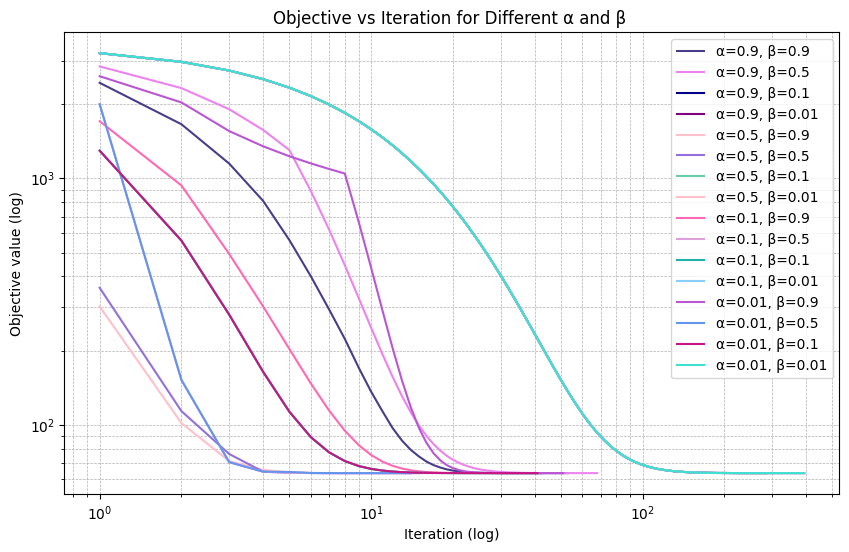

In [39]:
# ---------------------------------------------------------------------
# Experiments 1: objective vs iterations for different alpha, beta
# ---------------------------------------------------------------------

# lam_for_gd = 1.0
# s_init = 1.0
# alphas = [0.9, 0.5, 0.1, 0.01]
# betas = [0.9, 0.5, 0.1, 0.01]

# # 1a) obj_vs_iter_alpha.png – fixed beta, varying alpha
# fixed_beta = 0.5
# plt.figure(figsize=(7, 5))
# for alpha in alphas:
#     _, objs = gradient_descent(X_train, y_train, lam_for_gd,
#                                s_init, alpha, fixed_beta)
#     it = np.arange(1, len(objs) + 1)
#     plt.plot(it, objs, label=fr"$\alpha={alpha}$")

# plt.xscale("log")
# plt.yscale("log")
# plt.xlabel("Iteration (log scale)")
# plt.ylabel("Objective value (log scale)")
# plt.title(fr"Objective vs iteration (fixed $\beta={fixed_beta}$)")
# plt.legend()
# plt.grid(True, which="both", ls="--", linewidth=0.5)
# plt.tight_layout()
# plt.savefig(os.path.join(FIG_DIR, "obj_vs_iter_alpha.png"), dpi=1200)



lam = 1.0   # regularization strength
s = 1.0     # initial step size

alpha_values = [0.9, 0.5, 0.1, 0.01]
beta_values = [0.9, 0.5, 0.1, 0.01]
colors = ["darkslateblue", "violet", "darkblue", "purple", "pink", "mediumpurple", "mediumaquamarine", "pink", 'hotpink', 'plum', 
          'lightseagreen', 'lightskyblue', 'mediumorchid', 'cornflowerblue', 'mediumvioletred', 'turquoise']


results = {}

for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        results[(alpha, beta)] = obj_values
        print(f"α={alpha}, β={beta}, final objective={obj_values[-1]:.4f}")

# --- Plot ---
plt.figure(figsize=(10,6))

for i, ((alpha, beta), obj_values) in enumerate(results.items()):
    label = f"α={alpha}, β={beta}"
    iterations = np.arange(1, len(obj_values) + 1)
    plt.plot(iterations, obj_values, label=label, color=colors[i])

# for (alpha, beta), obj_values in results.items():
#     label = f"α={alpha}, β={beta}"
#     iterations = np.arange(1, len(obj_values) + 1)
#     plt.plot(iterations, obj_values, label=label)

plt.xscale('log')   # <-- Logarithmic x-axis (iterations)
plt.yscale('log')   # <-- Logarithmic y-axis (objective values)
plt.xlabel('Iteration (log)')
plt.ylabel('Objective value (log)')
plt.title('Objective vs Iteration for Different α and β ')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "obv_vs_it.png")
plt.savefig(downloads_path, dpi=1200)



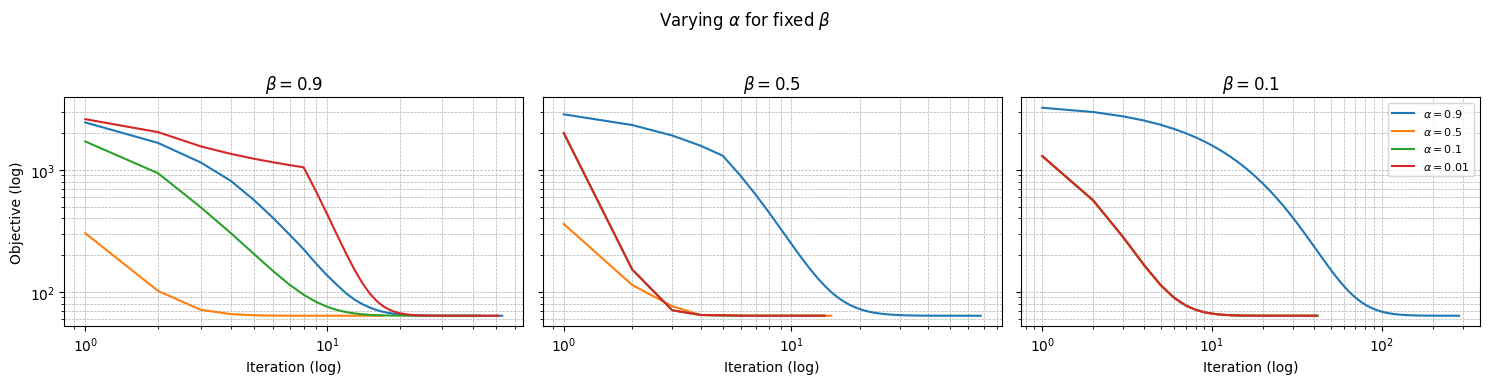

In [11]:
# 1b) plot2.png – 3-panel: varying alpha for several fixed betas
panel_betas = [0.9, 0.5, 0.1]
fig, axes = plt.subplots(1, len(panel_betas), figsize=(15, 4), sharey=True)
for ax, beta in zip(axes, panel_betas):
    for alpha in alphas:
        _, objs = gradient_descent(X_train, y_train, lam_for_gd,
                                   s_init, alpha, beta)
        it = np.arange(1, len(objs) + 1)
        ax.plot(it, objs, label=fr"$\alpha={alpha}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration (log)")
    ax.set_title(fr"$\beta={beta}$")
    ax.grid(True, which="both", ls="--", linewidth=0.5)

axes[0].set_ylabel("Objective (log)")
axes[-1].legend(loc="best", fontsize=8)
fig.suptitle("Varying $\\alpha$ for fixed $\\beta$")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(os.path.join(FIG_DIR, "plot2.png"), dpi=1200)


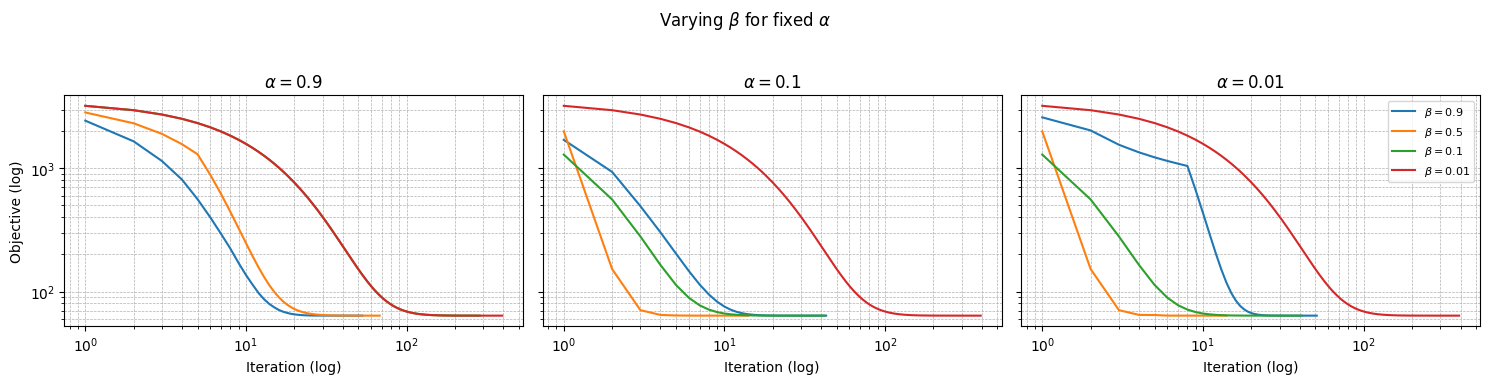

In [ ]:
# 1c) plot7.png – 3-panel: varying beta for several fixed alphas
panel_alphas = [0.9, 0.1, 0.01]
fig, axes = plt.subplots(1, len(panel_alphas), figsize=(15, 4), sharey=True)
for ax, alpha in zip(axes, panel_alphas):
    for beta in betas:
        _, objs = gradient_descent(X_train, y_train, lam_for_gd,
                                   s_init, alpha, beta)
        it = np.arange(1, len(objs) + 1)
        ax.plot(it, objs, label=fr"$\beta={beta}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration (log)")
    ax.set_title(fr"$\alpha={alpha}$")
    ax.grid(True, which="both", ls="--", linewidth=0.5)

axes[0].set_ylabel("Objective (log)")
axes[-1].legend(loc="best", fontsize=8)
fig.suptitle("Varying $\\beta$ for fixed $\\alpha$")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.savefig(os.path.join(FIG_DIR, "plot7.png"), dpi=1200)


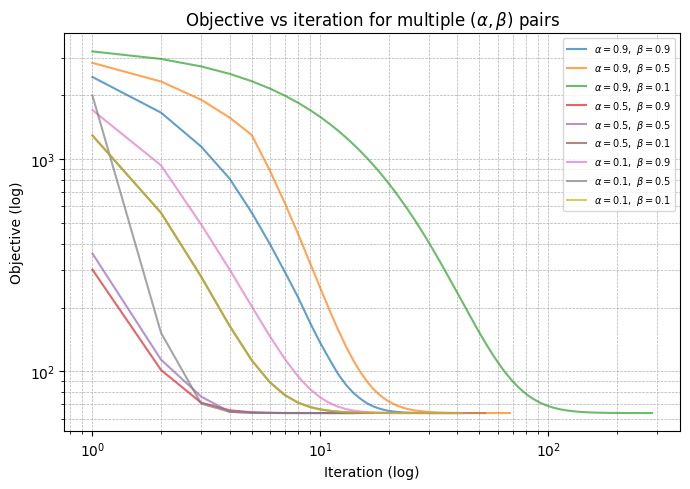

In [13]:
# 1d) plot1.png – combined plot for several (alpha, beta) pairs
plt.figure(figsize=(7, 5))
for alpha in [0.9, 0.5, 0.1]:
    for beta in [0.9, 0.5, 0.1]:
        _, objs = gradient_descent(X_train, y_train, lam_for_gd,
                                   s_init, alpha, beta)
        it = np.arange(1, len(objs) + 1)
        plt.plot(it, objs,
                 label=fr"$\alpha={alpha},\ \beta={beta}$",
                 alpha=0.7)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Iteration (log)")
plt.ylabel("Objective (log)")
plt.title("Objective vs iteration for multiple $(\\alpha, \\beta)$ pairs")
plt.legend(fontsize=7)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "plot1.png"), dpi=1200)


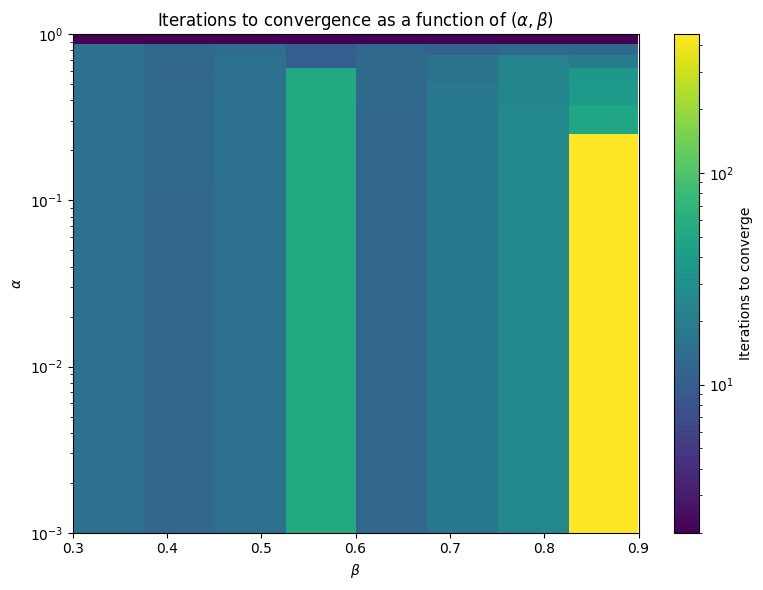

In [66]:
# ---------------------------------------------------------------------
# Experiments 2: heatmap of convergence speed in (alpha, beta)
# ---------------------------------------------------------------------

heat_alphas = np.logspace(-3, 0, 8)   # 1e-3 to 1
heat_betas = np.linspace(0.3, 0.9, 8) # 0.3 to 0.9
max_iter_heat = 500

iters_to_converge = np.zeros((len(heat_alphas), len(heat_betas)))

for i, alpha in enumerate(heat_alphas):
    for j, beta in enumerate(heat_betas):
        _, objs = gradient_descent(X_train, y_train, lam_for_gd,
                                   s_init, alpha, beta,
                                   max_iter=max_iter_heat, tol=1e-4)
        iters_to_converge[i, j] = len(objs)

# Avoid zeros for LogNorm
iters_to_converge[iters_to_converge <= 0] = max_iter_heat

plt.figure(figsize=(8, 6))
im = plt.imshow(iters_to_converge,
                origin="lower",
                aspect="auto",
                extent=[heat_betas[0], heat_betas[-1],
                        heat_alphas[0], heat_alphas[-1]],
                norm=LogNorm())
plt.colorbar(im, label="Iterations to converge")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.yscale("log")
plt.title("Iterations to convergence as a function of $(\\alpha, \\beta)$")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "heatmap_ab.png"), dpi=1200)


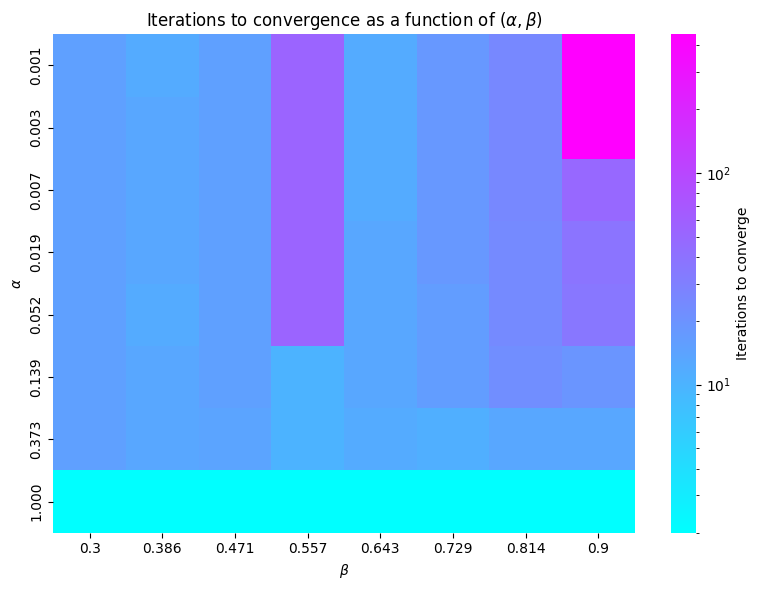

In [69]:
# Your data generation
heat_alphas = np.logspace(-3, 0, 8)   # 1e-3 to 1
heat_betas = np.linspace(0.3, 0.9, 8) # 0.3 to 0.9
max_iter_heat = 500

iters_to_converge = np.zeros((len(heat_alphas), len(heat_betas)))

for i, alpha in enumerate(heat_alphas):
    for j, beta in enumerate(heat_betas):
        _, objs = gradient_descent(X_train, y_train, lam_for_gd,
                                   s_init, alpha, beta,
                                   max_iter=max_iter_heat, tol=1e-4)
        iters_to_converge[i, j] = len(objs)

# Avoid zeros for LogNorm
iters_to_converge[iters_to_converge <= 0] = max_iter_heat

# ---- Seaborn Heatmap ----
plt.figure(figsize=(8, 6))

sns.heatmap(
    iters_to_converge,
    xticklabels=np.round(heat_betas, 3),
    yticklabels=[f"{a:.3f}" for a in heat_alphas],
    norm=LogNorm(),
    cmap="cool",
    cbar_kws={"label": "Iterations to converge"}
)

plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.title("Iterations to convergence as a function of $(\\alpha, \\beta)$")

plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "iterations_a_b.png")

plt.savefig(downloads_path, dpi=1200)
plt.show()

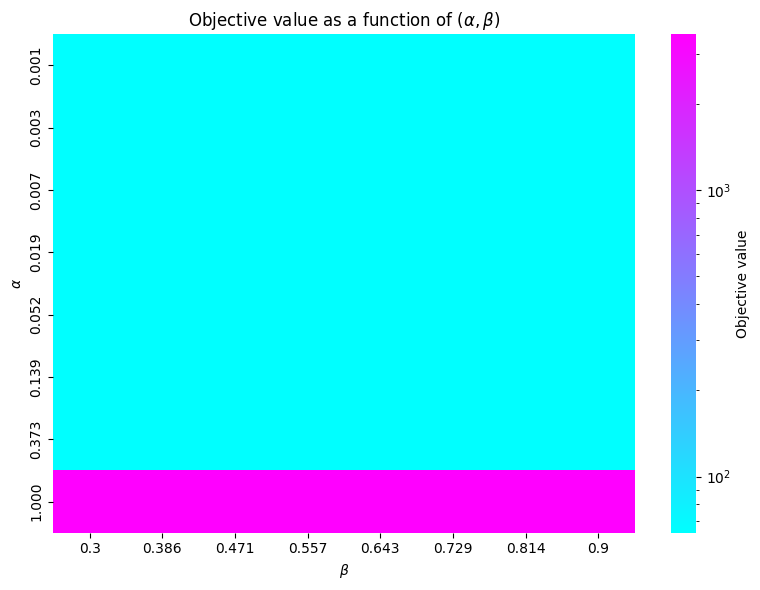

In [71]:
# Your data generation
heat_alphas = np.logspace(-3, 0, 8)
heat_betas = np.linspace(0.3, 0.9, 8)
max_iter_heat = 5000

obj_values = np.zeros((len(heat_alphas), len(heat_betas)))

for i, alpha in enumerate(heat_alphas):
    for j, beta in enumerate(heat_betas):

        s_out, objs = gradient_descent(X_train, y_train, lam_for_gd,
                                       s_init, alpha, beta,
                                       max_iter=max_iter_heat, tol=1e-4)

        obj_values[i, j] = objs[-1] 


plt.figure(figsize=(8, 6))

sns.heatmap(
    obj_values,
    xticklabels=np.round(heat_betas, 3),
    yticklabels=[f"{a:.3f}" for a in heat_alphas],
    norm=LogNorm(),        # log-scale color mapping
    cmap="cool",           # blue → pink gradient
    cbar_kws={"label": "Objective value"}
)

plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.title("Objective value as a function of $(\\alpha, \\beta)$")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "heatmap_obj_seaborn.png"), dpi=1200)
plt.show()

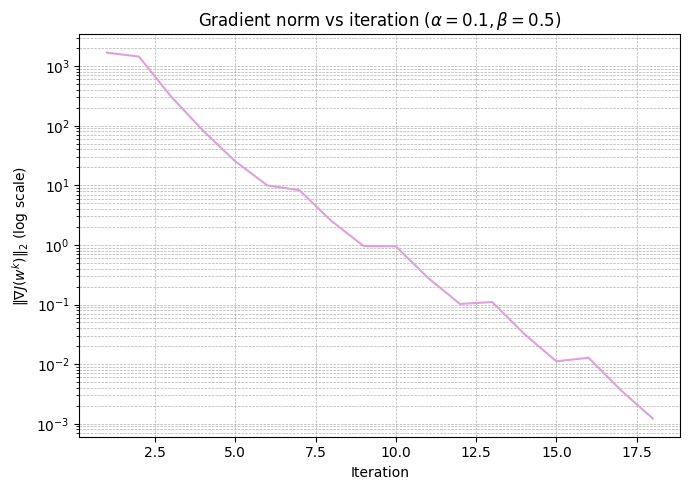

In [41]:
# ---------------------------------------------------------------------
# Experiments 3: norm vs iteration for a representative (alpha, beta)
# ---------------------------------------------------------------------

alpha_example = 0.1
beta_example = 0.5

_, obj_vals_ex, grad_norms_ex, param_norms_ex, step_sizes_ex = \
    gradient_descent_with_norms(X_train, y_train, lam_for_gd,
                                s_init, alpha_example, beta_example,
                                max_iter=1000, tol=1e-8)

its = np.arange(1, len(grad_norms_ex) + 1)

plt.figure(figsize=(7, 5))
plt.plot(its, grad_norms_ex, color='plum')
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel(r"$\|\nabla J(w^k)\|_2$ (log scale)")
plt.title(fr"Gradient norm vs iteration ($\alpha={alpha_example}, \beta={beta_example}$)")
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "norm_v_it.png")

plt.savefig(downloads_path, dpi=1200)

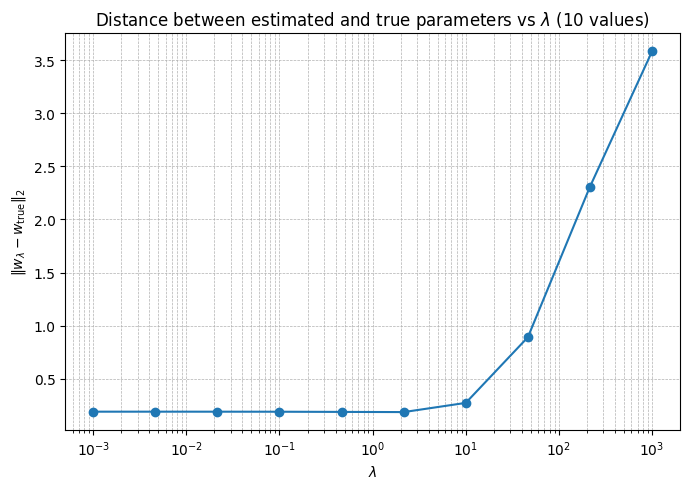

In [18]:
# 10 lambda values
lambdas_10 = np.logspace(-3, 3, 10)
errors_10 = []

for lam in lambdas_10:
    w_lam = ridge_closed_form(X_train, y_train, lam)
    errors_10.append(np.linalg.norm(w_lam - w_true))

plt.figure(figsize=(7, 5))
plt.semilogx(lambdas_10, errors_10, marker="o")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\|w_\lambda - w_{\text{true}}\|_2$")
plt.title(r"Distance between estimated and true parameters vs $\lambda$ (10 values)")
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "plot5.png"), dpi=1200)


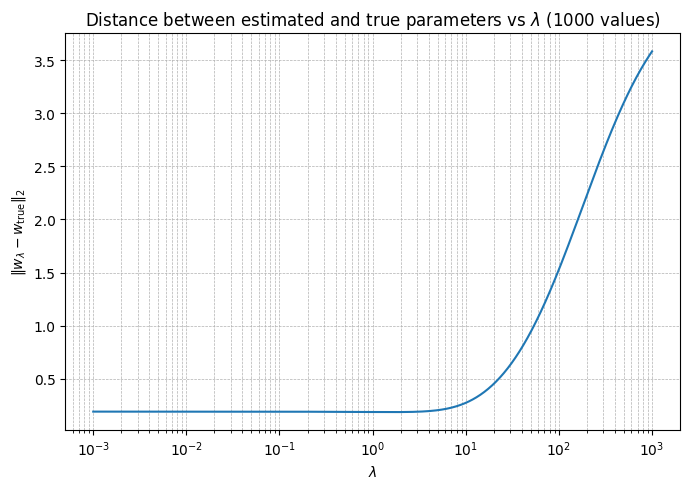

In [19]:
lambdas_1000 = np.logspace(-3, 3, 1000)
errors_1000 = []

for lam in lambdas_1000:
    w_lam = ridge_closed_form(X_train, y_train, lam)
    errors_1000.append(np.linalg.norm(w_lam - w_true))

plt.figure(figsize=(7, 5))
plt.semilogx(lambdas_1000, errors_1000)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\|w_\lambda - w_{\text{true}}\|_2$")
plt.title(r"Distance between estimated and true parameters vs $\lambda$ (1000 values)")
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "plot6.png"), dpi=1200)

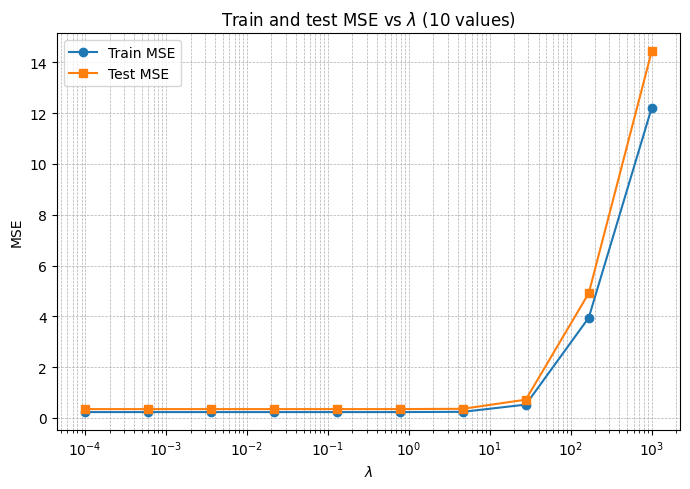

In [20]:
lambdas_10_mse = np.logspace(-4, 3, 10)
mse_train_10 = []
mse_test_10 = []

for lam in lambdas_10_mse:
    w_lam = ridge_closed_form(X_train, y_train, lam)
    mse_train_10.append(mse(X_train, y_train, w_lam))
    mse_test_10.append(mse(X_test, y_test, w_lam))

plt.figure(figsize=(7, 5))
plt.semilogx(lambdas_10_mse, mse_train_10, marker="o", label="Train MSE")
plt.semilogx(lambdas_10_mse, mse_test_10, marker="s", label="Test MSE")
plt.xlabel(r"$\lambda$")
plt.ylabel("MSE")
plt.title("Train and test MSE vs $\\lambda$ (10 values)")
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "plot8.png"), dpi=1200)


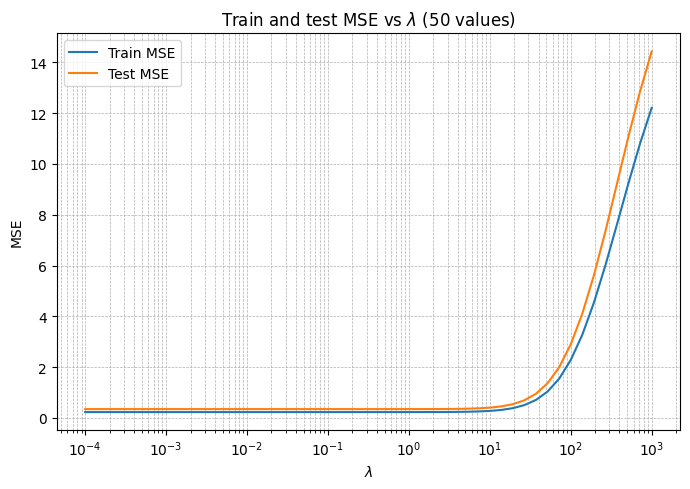

In [22]:
lambdas_50 = np.logspace(-4, 3, 50)
mse_train_50 = []
mse_test_50 = []

for lam in lambdas_50:
    w_lam = ridge_closed_form(X_train, y_train, lam)
    mse_train_50.append(mse(X_train, y_train, w_lam))
    mse_test_50.append(mse(X_test, y_test, w_lam))

plt.figure(figsize=(7, 5))
plt.semilogx(lambdas_50, mse_train_50, label="Train MSE")
plt.semilogx(lambdas_50, mse_test_50, label="Test MSE")
plt.xlabel(r"$\lambda$")
plt.ylabel("MSE")
plt.title("Train and test MSE vs $\\lambda$ (50 values)")
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "plot9.png"), dpi=1200)


In [25]:
def gradient_descent_tracked(X, y, lam, s, alpha, beta, max_iter=1000):
    w = np.zeros(X.shape[1])
    obj_values = []
    w_trajectory = [w.copy()]
    
    for _ in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta
        w = w - t * grad
        obj_values.append(ridge_objective(X, y, w, lam))
        w_trajectory.append(w.copy())
    
    return w, obj_values, w_trajectory

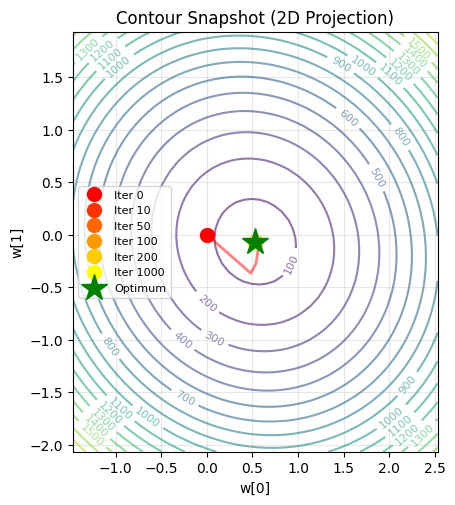

In [29]:
# Run optimization
lam = 1.0
s, alpha, beta = 1.0, 0.3, 0.5
w_opt, obj_vals, w_traj = gradient_descent_tracked(X_train, y_train, lam, s, alpha, beta)
w_closed = ridge_closed_form(X_train, y_train, lam)
f_star = ridge_objective(X_train, y_train, w_closed, lam)

# Create comprehensive diagnostic plots
fig = plt.figure(figsize=(16, 12))

# 1. Contour Snapshots (2D projection using first two weights)
ax1 = plt.subplot(2, 3, 1)
w1_range = np.linspace(w_closed[0] - 2, w_closed[0] + 2, 50)
w2_range = np.linspace(w_closed[1] - 2, w_closed[1] + 2, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z_contour = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_temp = w_closed.copy()
        w_temp[0] = W1[i, j]
        w_temp[1] = W2[i, j]
        Z_contour[i, j] = ridge_objective(X_train, y_train, w_temp, lam)

contour = ax1.contour(W1, W2, Z_contour, levels=20, cmap='viridis', alpha=0.6)
ax1.clabel(contour, inline=True, fontsize=8)

# Plot trajectory
w_traj_array = np.array(w_traj)
snapshot_indices = [0, 10, 50, 100, 200, len(w_traj)-1]
colors = plt.cm.autumn(np.linspace(0, 1, len(snapshot_indices)))

for idx, snap_idx in enumerate(snapshot_indices):
    if snap_idx < len(w_traj):
        ax1.plot(w_traj_array[snap_idx, 0], w_traj_array[snap_idx, 1], 
                'o', color=colors[idx], markersize=10, 
                label=f'Iter {snap_idx}', zorder=5)

ax1.plot(w_traj_array[:, 0], w_traj_array[:, 1], 'r-', alpha=0.5, linewidth=2)
ax1.plot(w_closed[0], w_closed[1], 'g*', markersize=20, label='Optimum', zorder=6)
ax1.set_xlabel('w[0]')
ax1.set_ylabel('w[1]')
ax1.set_title('Contour Snapshot (2D Projection)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)




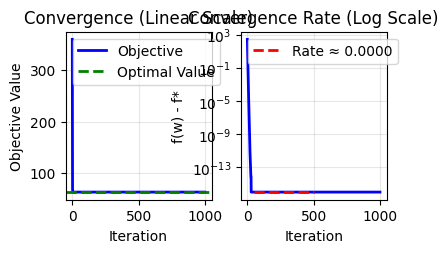

In [32]:
# 2. Convergence Rate - Linear Scale
ax2 = plt.subplot(2, 3, 2)
iterations = np.arange(len(obj_vals))
ax2.plot(iterations, obj_vals, 'b-', linewidth=2, label='Objective')
ax2.axhline(y=f_star, color='g', linestyle='--', linewidth=2, label='Optimal Value')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Objective Value')
ax2.set_title('Convergence (Linear Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Convergence Rate - Log Scale
ax3 = plt.subplot(2, 3, 3)
optimality_gap = np.array(obj_vals) - f_star
optimality_gap = np.maximum(optimality_gap, 1e-16)  # Avoid log(0)
ax3.semilogy(iterations, optimality_gap, 'b-', linewidth=2)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('f(w) - f*')
ax3.set_title('Convergence Rate (Log Scale)')
ax3.grid(True, alpha=0.3, which='both')

# Estimate convergence rate
if len(optimality_gap) > 100:
    start_idx = 50
    end_idx = min(500, len(optimality_gap))
    log_gap = np.log(optimality_gap[start_idx:end_idx])
    iters = np.arange(start_idx, end_idx)
    coeffs = np.polyfit(iters, log_gap, 1)
    rate = coeffs[0]
    ax3.plot(iters, np.exp(np.polyval(coeffs, iters)), 'r--', 
             linewidth=2, label=f'Rate ≈ {rate:.4f}')
    ax3.legend()
    

/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_61587/3969468126.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax6.legend()


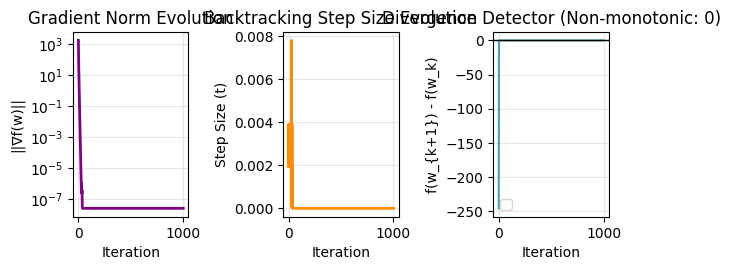

CONVERGENCE DIAGNOSTICS SUMMARY
Total iterations: 1000
Initial objective: 359.876921
Final objective: 63.670607
Optimal objective: 63.670607
Final optimality gap: -2.842171e-14
Non-monotonic steps: 0
Final gradient norm: 2.476227e-08
Average step size (last 100 iters): 0.000000


In [28]:

# 4. Gradient Norm Evolution
ax4 = plt.subplot(2, 3, 4)
grad_norms = []
for w in w_traj[:-1]:
    grad = ridge_grad(X_train, y_train, w, lam)
    grad_norms.append(np.linalg.norm(grad))

ax4.semilogy(grad_norms, 'purple', linewidth=2)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('||∇f(w)||')
ax4.set_title('Gradient Norm Evolution')
ax4.grid(True, alpha=0.3, which='both')

# 5. Divergence Detector - Step Size Behavior
ax5 = plt.subplot(2, 3, 5)
# Re-run with tracking of step sizes
def gd_with_step_tracking(X, y, lam, s, alpha, beta, max_iter=1000):
    w = np.zeros(X.shape[1])
    step_sizes = []
    
    for _ in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        t = s
        backtrack_count = 0
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta
            backtrack_count += 1
            if backtrack_count > 50:  # Safety check
                break
        w = w - t * grad
        step_sizes.append(t)
    
    return step_sizes

step_sizes = gd_with_step_tracking(X_train, y_train, lam, s, alpha, beta)
ax5.plot(step_sizes, 'darkorange', linewidth=2)
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Step Size (t)')
ax5.set_title('Backtracking Step Size Evolution')
ax5.grid(True, alpha=0.3)

# 6. Divergence Detector - Objective Monotonicity Check
ax6 = plt.subplot(2, 3, 6)
obj_diff = np.diff(obj_vals)
divergence_events = np.where(obj_diff > 0)[0]

ax6.plot(obj_diff, 'teal', linewidth=1.5, alpha=0.7)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
if len(divergence_events) > 0:
    ax6.scatter(divergence_events, obj_diff[divergence_events], 
                color='red', s=50, zorder=5, label='Non-monotonic')
ax6.set_xlabel('Iteration')
ax6.set_ylabel('f(w_{k+1}) - f(w_k)')
ax6.set_title(f'Divergence Detector (Non-monotonic: {len(divergence_events)})')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("="*60)
print("CONVERGENCE DIAGNOSTICS SUMMARY")
print("="*60)
print(f"Total iterations: {len(obj_vals)}")
print(f"Initial objective: {obj_vals[0]:.6f}")
print(f"Final objective: {obj_vals[-1]:.6f}")
print(f"Optimal objective: {f_star:.6f}")
print(f"Final optimality gap: {obj_vals[-1] - f_star:.6e}")
print(f"Non-monotonic steps: {len(divergence_events)}")
print(f"Final gradient norm: {grad_norms[-1]:.6e}")
print(f"Average step size (last 100 iters): {np.mean(step_sizes[-100:]):.6f}")
print("="*60)

/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_61587/3909730486.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax6.legend()


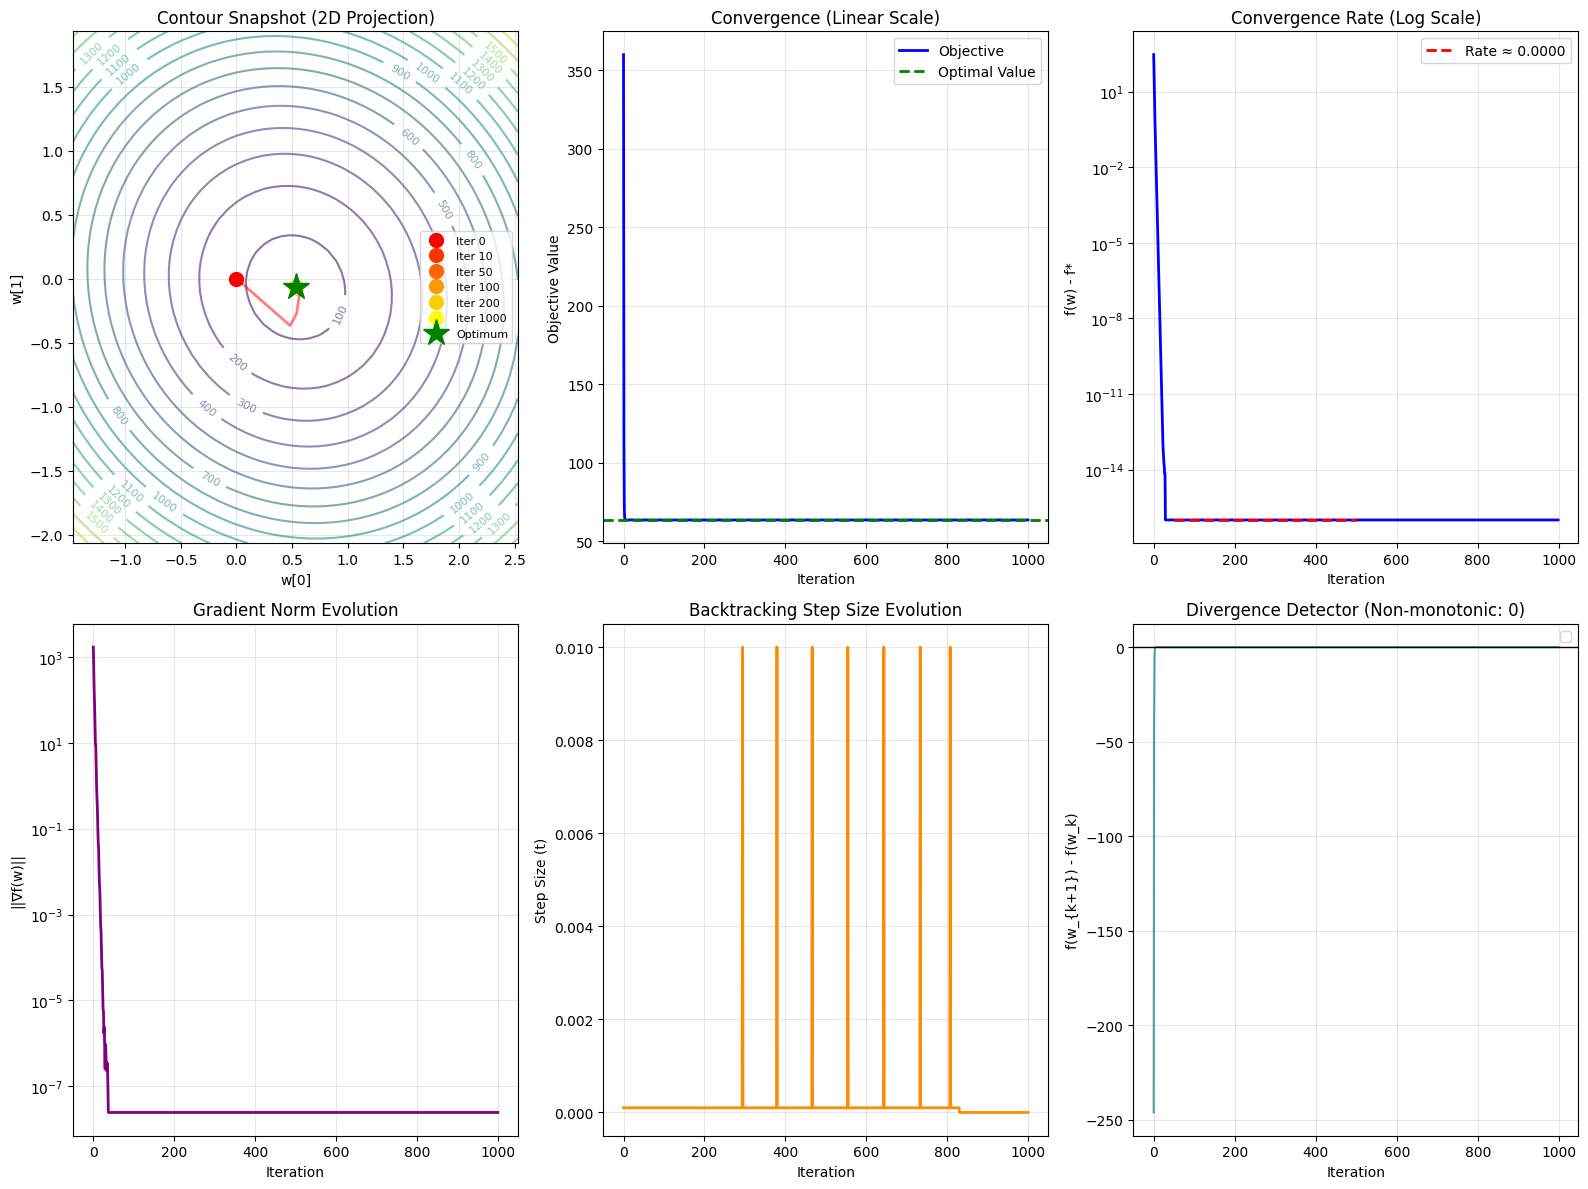

CONVERGENCE DIAGNOSTICS SUMMARY
Total iterations: 1000
Initial objective: 359.876921
Final objective: 63.670607
Optimal objective: 63.670607
Final optimality gap: -2.842171e-14
Non-monotonic steps: 0
Final gradient norm: 2.476227e-08
Average step size (last 100 iters): 0.000000


In [42]:
# Create comprehensive diagnostic plots
fig = plt.figure(figsize=(16, 12))

# 1. Contour Snapshots (2D projection using first two weights)
ax1 = plt.subplot(2, 3, 1)
w1_range = np.linspace(w_closed[0] - 2, w_closed[0] + 2, 50)
w2_range = np.linspace(w_closed[1] - 2, w_closed[1] + 2, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z_contour = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_temp = w_closed.copy()
        w_temp[0] = W1[i, j]
        w_temp[1] = W2[i, j]
        Z_contour[i, j] = ridge_objective(X_train, y_train, w_temp, lam)

contour = ax1.contour(W1, W2, Z_contour, levels=20, cmap='viridis', alpha=0.6)
ax1.clabel(contour, inline=True, fontsize=8)

# Plot trajectory
w_traj_array = np.array(w_traj)
snapshot_indices = [0, 10, 50, 100, 200, len(w_traj)-1]
colors = plt.cm.autumn(np.linspace(0, 1, len(snapshot_indices)))

for idx, snap_idx in enumerate(snapshot_indices):
    if snap_idx < len(w_traj):
        ax1.plot(w_traj_array[snap_idx, 0], w_traj_array[snap_idx, 1], 
                'o', color=colors[idx], markersize=10, 
                label=f'Iter {snap_idx}', zorder=5)

ax1.plot(w_traj_array[:, 0], w_traj_array[:, 1], 'r-', alpha=0.5, linewidth=2)
ax1.plot(w_closed[0], w_closed[1], 'g*', markersize=20, label='Optimum', zorder=6)
ax1.set_xlabel('w[0]')
ax1.set_ylabel('w[1]')
ax1.set_title('Contour Snapshot (2D Projection)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Convergence Rate - Linear Scale
ax2 = plt.subplot(2, 3, 2)
iterations = np.arange(len(obj_vals))
ax2.plot(iterations, obj_vals, 'b-', linewidth=2, label='Objective')
ax2.axhline(y=f_star, color='g', linestyle='--', linewidth=2, label='Optimal Value')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Objective Value')
ax2.set_title('Convergence (Linear Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Convergence Rate - Log Scale
ax3 = plt.subplot(2, 3, 3)
optimality_gap = np.array(obj_vals) - f_star
optimality_gap = np.maximum(optimality_gap, 1e-16)  # Avoid log(0)
ax3.semilogy(iterations, optimality_gap, 'b-', linewidth=2)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('f(w) - f*')
ax3.set_title('Convergence Rate (Log Scale)')
ax3.grid(True, alpha=0.3, which='both')

# Estimate convergence rate
if len(optimality_gap) > 100:
    start_idx = 50
    end_idx = min(500, len(optimality_gap))
    log_gap = np.log(optimality_gap[start_idx:end_idx])
    iters = np.arange(start_idx, end_idx)
    coeffs = np.polyfit(iters, log_gap, 1)
    rate = coeffs[0]
    ax3.plot(iters, np.exp(np.polyval(coeffs, iters)), 'r--', 
             linewidth=2, label=f'Rate ≈ {rate:.4f}')
    ax3.legend()

# 4. Gradient Norm Evolution
ax4 = plt.subplot(2, 3, 4)
grad_norms = []
for w in w_traj[:-1]:
    grad = ridge_grad(X_train, y_train, w, lam)
    grad_norms.append(np.linalg.norm(grad))

ax4.semilogy(grad_norms, 'purple', linewidth=2)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('||∇f(w)||')
ax4.set_title('Gradient Norm Evolution')
ax4.grid(True, alpha=0.3, which='both')

# 5. Divergence Detector - Step Size Behavior
ax5 = plt.subplot(2, 3, 5)
# Re-run with tracking of step sizes
def gd_with_step_tracking(X, y, lam, s, alpha, beta, max_iter=1000):
    w = np.zeros(X.shape[1])
    step_sizes = []
    
    for _ in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        t = s
        backtrack_count = 0
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta
            backtrack_count += 1
            if backtrack_count > 50:  # Safety check
                break
        w = w - t * grad
        step_sizes.append(t)
    
    return step_sizes

step_sizes = gd_with_step_tracking(X_train, y_train, lam, s, alpha, beta)
ax5.plot(step_sizes, 'darkorange', linewidth=2)
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Step Size (t)')
ax5.set_title('Backtracking Step Size Evolution')
ax5.grid(True, alpha=0.3)

# 6. Divergence Detector - Objective Monotonicity Check
ax6 = plt.subplot(2, 3, 6)
obj_diff = np.diff(obj_vals)
divergence_events = np.where(obj_diff > 0)[0]

ax6.plot(obj_diff, 'teal', linewidth=1.5, alpha=0.7)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
if len(divergence_events) > 0:
    ax6.scatter(divergence_events, obj_diff[divergence_events], 
                color='red', s=50, zorder=5, label='Non-monotonic')
ax6.set_xlabel('Iteration')
ax6.set_ylabel('f(w_{k+1}) - f(w_k)')
ax6.set_title(f'Divergence Detector (Non-monotonic: {len(divergence_events)})')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("="*60)
print("CONVERGENCE DIAGNOSTICS SUMMARY")
print("="*60)
print(f"Total iterations: {len(obj_vals)}")
print(f"Initial objective: {obj_vals[0]:.6f}")
print(f"Final objective: {obj_vals[-1]:.6f}")
print(f"Optimal objective: {f_star:.6f}")
print(f"Final optimality gap: {obj_vals[-1] - f_star:.6e}")
print(f"Non-monotonic steps: {len(divergence_events)}")
print(f"Final gradient norm: {grad_norms[-1]:.6e}")
print(f"Average step size (last 100 iters): {np.mean(step_sizes[-100:]):.6f}")
print("="*60)

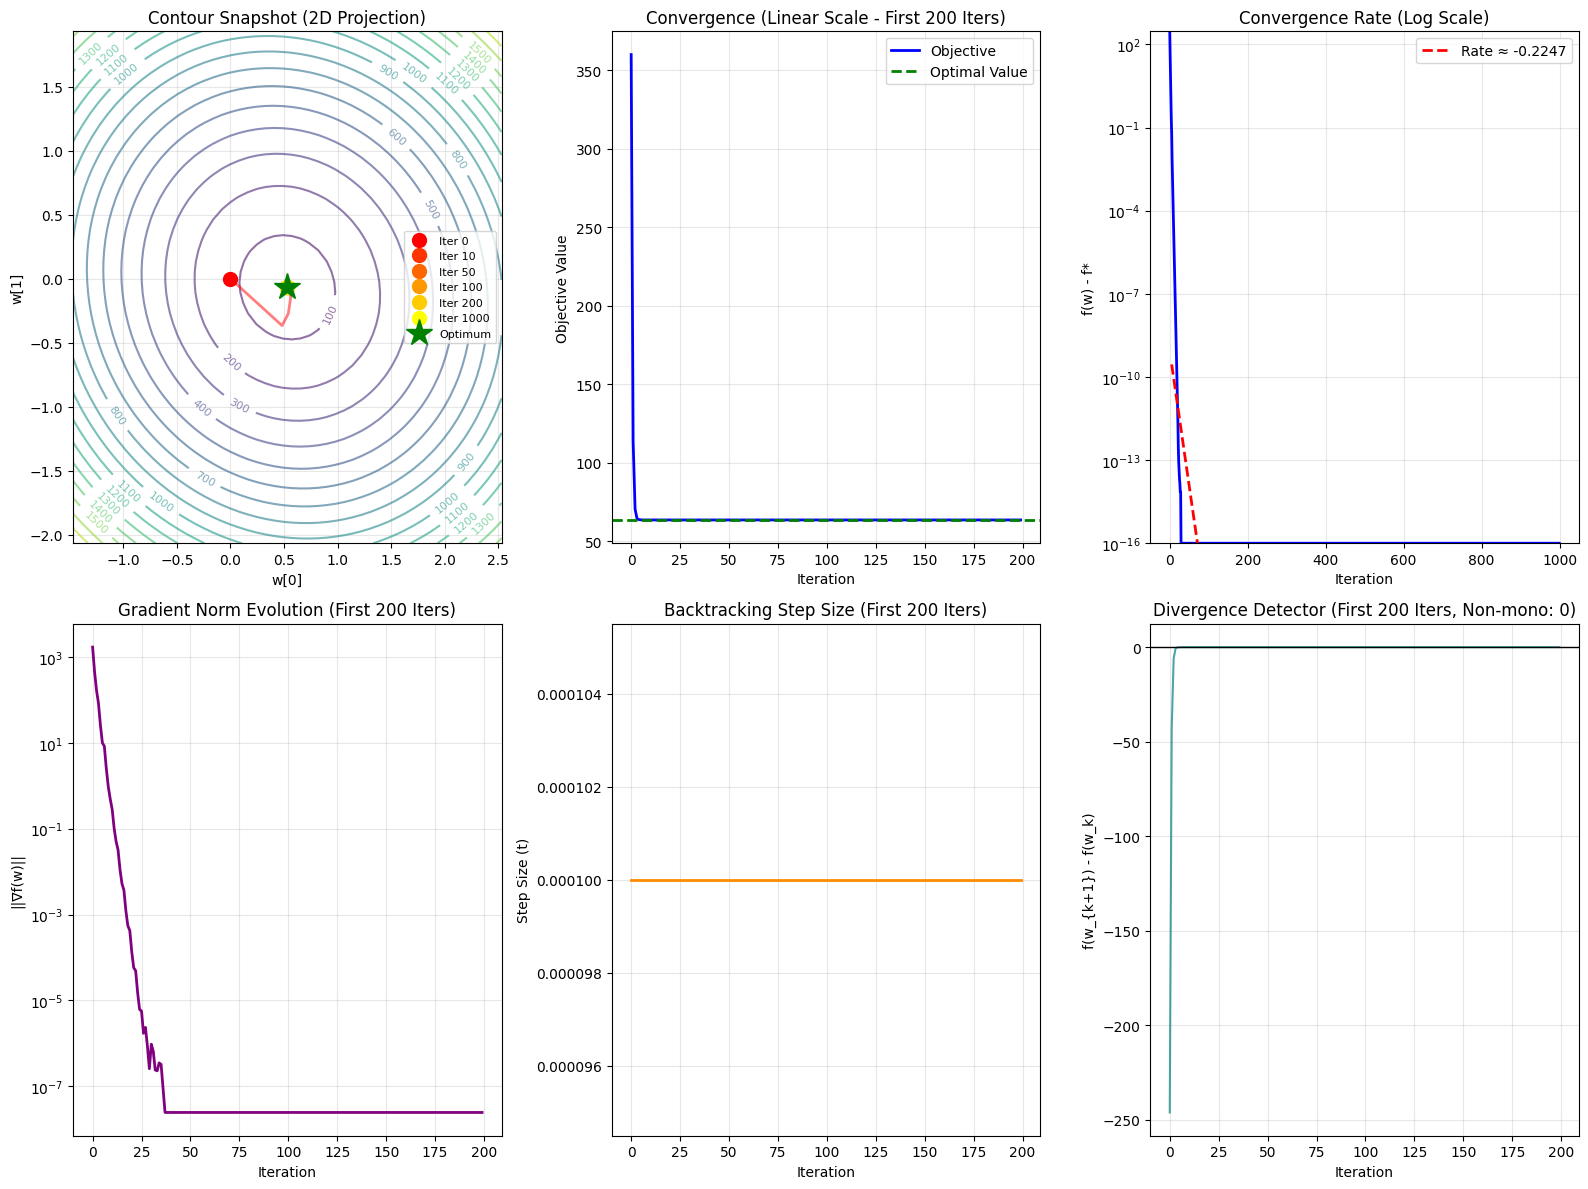

CONVERGENCE DIAGNOSTICS SUMMARY
Total iterations: 1000
Initial objective: 359.876921
Final objective: 63.670607
Optimal objective: 63.670607
Final optimality gap: -2.842171e-14
Non-monotonic steps: 0
Final gradient norm: 2.476227e-08
Average step size (last 100 iters): 0.000000


In [43]:
# Create comprehensive diagnostic plots
fig = plt.figure(figsize=(16, 12))

# 1. Contour Snapshots (2D projection using first two weights)
ax1 = plt.subplot(2, 3, 1)
w1_range = np.linspace(w_closed[0] - 2, w_closed[0] + 2, 50)
w2_range = np.linspace(w_closed[1] - 2, w_closed[1] + 2, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z_contour = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_temp = w_closed.copy()
        w_temp[0] = W1[i, j]
        w_temp[1] = W2[i, j]
        Z_contour[i, j] = ridge_objective(X_train, y_train, w_temp, lam)

contour = ax1.contour(W1, W2, Z_contour, levels=20, cmap='viridis', alpha=0.6)
ax1.clabel(contour, inline=True, fontsize=8)

# Plot trajectory
w_traj_array = np.array(w_traj)
snapshot_indices = [0, 10, 50, 100, 200, len(w_traj)-1]
colors = plt.cm.autumn(np.linspace(0, 1, len(snapshot_indices)))

for idx, snap_idx in enumerate(snapshot_indices):
    if snap_idx < len(w_traj):
        ax1.plot(w_traj_array[snap_idx, 0], w_traj_array[snap_idx, 1], 
                'o', color=colors[idx], markersize=10, 
                label=f'Iter {snap_idx}', zorder=5)

ax1.plot(w_traj_array[:, 0], w_traj_array[:, 1], 'r-', alpha=0.5, linewidth=2)
ax1.plot(w_closed[0], w_closed[1], 'g*', markersize=20, label='Optimum', zorder=6)
ax1.set_xlabel('w[0]')
ax1.set_ylabel('w[1]')
ax1.set_title('Contour Snapshot (2D Projection)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Convergence Rate - Linear Scale (First 200 iterations for visibility)
ax2 = plt.subplot(2, 3, 2)
iterations = np.arange(len(obj_vals))
plot_range = min(200, len(obj_vals))
ax2.plot(iterations[:plot_range], obj_vals[:plot_range], 'b-', linewidth=2, label='Objective')
ax2.axhline(y=f_star, color='g', linestyle='--', linewidth=2, label='Optimal Value')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Objective Value')
ax2.set_title('Convergence (Linear Scale - First 200 Iters)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Convergence Rate - Log Scale
ax3 = plt.subplot(2, 3, 3)
optimality_gap = np.array(obj_vals) - f_star
optimality_gap = np.maximum(optimality_gap, 1e-16)  # Avoid log(0)
ax3.semilogy(iterations, optimality_gap, 'b-', linewidth=2)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('f(w) - f*')
ax3.set_title('Convergence Rate (Log Scale)')
ax3.set_ylim([1e-16, max(optimality_gap[:100])])  # Focus on meaningful range
ax3.grid(True, alpha=0.3, which='both')

# Estimate convergence rate (using early iterations where change is visible)
if len(optimality_gap) > 50:
    start_idx = 5
    end_idx = min(100, len(optimality_gap))
    log_gap = np.log(optimality_gap[start_idx:end_idx])
    iters = np.arange(start_idx, end_idx)
    coeffs = np.polyfit(iters, log_gap, 1)
    rate = coeffs[0]
    ax3.plot(iters, np.exp(np.polyval(coeffs, iters)), 'r--', 
             linewidth=2, label=f'Rate ≈ {rate:.4f}')
    ax3.legend()

# 4. Gradient Norm Evolution
ax4 = plt.subplot(2, 3, 4)
grad_norms = []
for w in w_traj[:-1]:
    grad = ridge_grad(X_train, y_train, w, lam)
    grad_norms.append(np.linalg.norm(grad))

# Plot first 200 iterations to see the descent pattern
plot_range = min(200, len(grad_norms))
ax4.semilogy(range(plot_range), grad_norms[:plot_range], 'purple', linewidth=2)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('||∇f(w)||')
ax4.set_title('Gradient Norm Evolution (First 200 Iters)')
ax4.grid(True, alpha=0.3, which='both')

# 5. Divergence Detector - Step Size Behavior
ax5 = plt.subplot(2, 3, 5)
# Re-run with tracking of step sizes
def gd_with_step_tracking(X, y, lam, s, alpha, beta, max_iter=1000):
    w = np.zeros(X.shape[1])
    step_sizes = []
    
    for _ in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        t = s
        backtrack_count = 0
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta
            backtrack_count += 1
            if backtrack_count > 50:  # Safety check
                break
        w = w - t * grad
        step_sizes.append(t)
    
    return step_sizes

step_sizes = gd_with_step_tracking(X_train, y_train, lam, s, alpha, beta)
# Plot first 200 iterations to see pattern
plot_range = min(200, len(step_sizes))
ax5.plot(range(plot_range), step_sizes[:plot_range], 'darkorange', linewidth=2)
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Step Size (t)')
ax5.set_title('Backtracking Step Size (First 200 Iters)')
ax5.grid(True, alpha=0.3)

# 6. Divergence Detector - Objective Monotonicity Check
ax6 = plt.subplot(2, 3, 6)
obj_diff = np.diff(obj_vals)
divergence_events = np.where(obj_diff > 0)[0]

# Plot first 200 iterations to see pattern
plot_range = min(200, len(obj_diff))
ax6.plot(range(plot_range), obj_diff[:plot_range], 'teal', linewidth=1.5, alpha=0.7)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
if len(divergence_events) > 0:
    div_in_range = divergence_events[divergence_events < plot_range]
    if len(div_in_range) > 0:
        ax6.scatter(div_in_range, obj_diff[div_in_range], 
                    color='red', s=50, zorder=5, label='Non-monotonic')
ax6.set_xlabel('Iteration')
ax6.set_ylabel('f(w_{k+1}) - f(w_k)')
ax6.set_title(f'Divergence Detector (First 200 Iters, Non-mono: {len(divergence_events)})')
if len(divergence_events) > 0:
    ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("="*60)
print("CONVERGENCE DIAGNOSTICS SUMMARY")
print("="*60)
print(f"Total iterations: {len(obj_vals)}")
print(f"Initial objective: {obj_vals[0]:.6f}")
print(f"Final objective: {obj_vals[-1]:.6f}")
print(f"Optimal objective: {f_star:.6f}")
print(f"Final optimality gap: {obj_vals[-1] - f_star:.6e}")
print(f"Non-monotonic steps: {len(divergence_events)}")
print(f"Final gradient norm: {grad_norms[-1]:.6e}")
print(f"Average step size (last 100 iters): {np.mean(step_sizes[-100:]):.6f}")
print("="*60)

In [47]:
try:
    from sklearn.decomposition import PCA
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False

# ---------------------------
# 1) Data generation (your code, cleaned)
# ---------------------------
np.random.seed(2025)
n, p, k = 500, 50, 8
sigma = 1.0

m = 10
Z = np.random.randn(n, m)
A = np.random.randn(m, p) * 0.8
X = Z.dot(A) + 0.1 * np.random.randn(n, p)

w_true = np.zeros(p)
w_true[:k] = np.linspace(5.0, 1.0, k) * np.random.choice([1, -1], k)
y = X.dot(w_true) + sigma * np.random.randn(n)

idx = np.random.permutation(n)
train_idx, test_idx = idx[:350], idx[350:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Precompute quantities for speed
XTX = X_train.T @ X_train
XTy = X_train.T @ y_train

# ---------------------------
# 2) Core ridge functions (clean, numerically stable)
# ---------------------------
def ridge_closed_form(X, y, lam):
    """Return ridge estimator w_hat = (X^T X + lam I)^{-1} X^T y"""
    A = X.T @ X + lam * np.eye(X.shape[1])
    b = X.T @ y
    return np.linalg.solve(A, b)

def ridge_objective(X, y, w, lam):
    r = X @ w - y
    return float(np.dot(r, r) + lam * np.dot(w, w))

def ridge_grad_from_precomp(XTX, XTy, w, lam):
    # gradient = 2 * (X^T (X w - y) + lam w) = 2 * (XTX w - XTy + lam w)
    return 2.0 * (XTX @ w - XTy + lam * w)

Reference f* = 3.799628e+02
Saved contour to figures/contour_projection.png


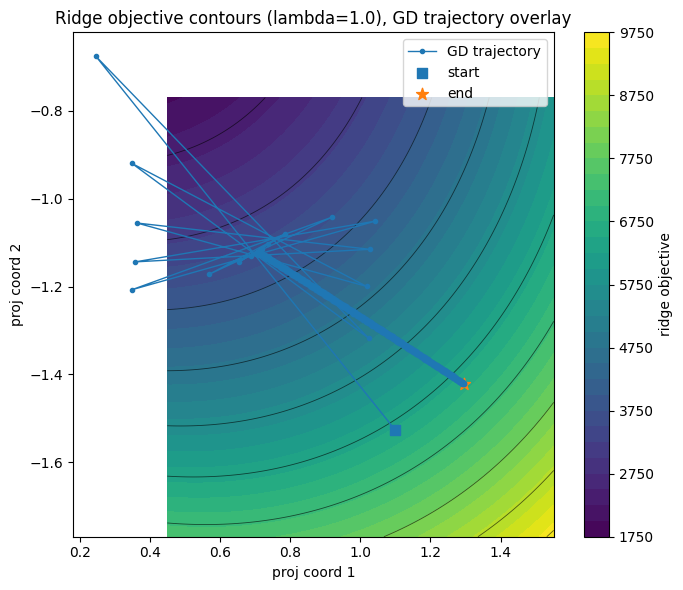

Saved convergence plot to figures/convergence_rate.png


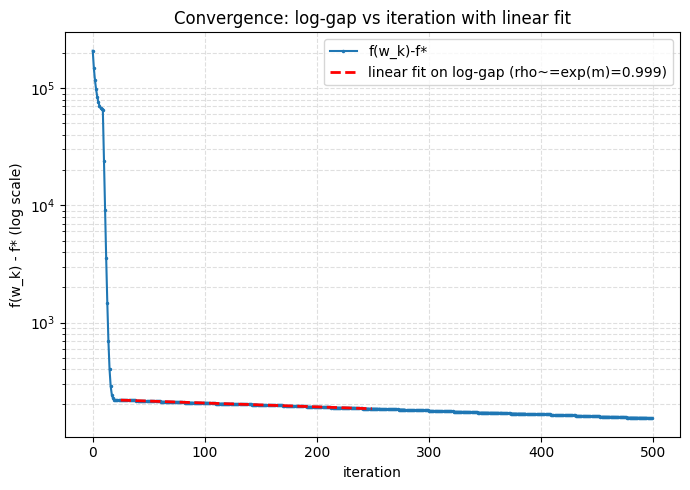

Estimated linear fit slope m = -7.554012e-04; implied rho = exp(m) = 9.992449e-01
Interpretation: if 0 < rho < 1 then gap decays roughly geometrically with factor rho per iteration.
Saved divergence detector to figures/divergence_detector.png


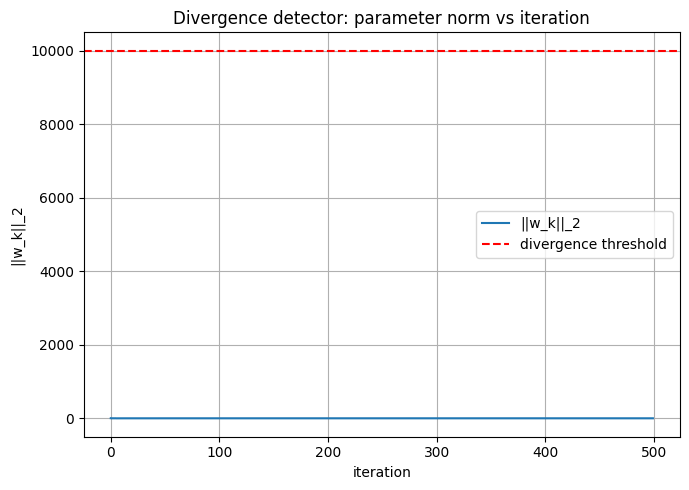

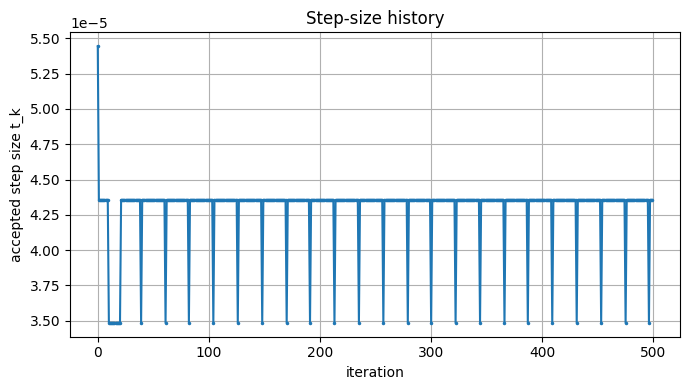

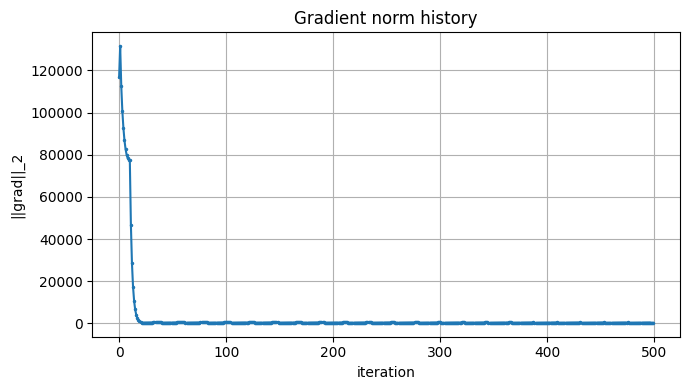

No divergence detected within max iterations and threshold.


In [48]:
# ---------------------------
# 3) Gradient descent with Armijo backtracking + tracking + divergence detector
# ---------------------------
def run_gd_armijo_track(X, y, XTX, XTy, lam=1.0, s_init=1.0, alpha=1e-3, beta=0.8,
                        maxit=1000, divergence_threshold=1e6, max_backtracks=200):
    """
    Return:
      ws : (T, p) array of parameter iterates
      objs: (T,) objective values
      t_hist: accepted step sizes
      grad_norms: gradient norms
      diverged: bool flag (True if divergence detected)
      diverged_at: iteration index or None
    """
    p = X.shape[1]
    w = np.zeros(p)
    ws = []
    objs = []
    t_hist = []
    grad_norms = []
    diverged = False
    diverged_at = None

    for it in range(maxit):
        g = ridge_grad_from_precomp(XTX, XTy, w, lam)
        t = s_init
        fcur = ridge_objective(X, y, w, lam)

        # Armijo backtracking
        backtrack_count = 0
        # Note: we cap number of backtracks for safety/perf
        while True:
            w_trial = w - t * g
            ftrial = ridge_objective(X, y, w_trial, lam)
            if ftrial <= fcur - alpha * t * np.dot(g, g):
                break
            t *= beta
            backtrack_count += 1
            if backtrack_count >= max_backtracks or t < 1e-20:
                # accept the latest t (even if Armijo not satisfied) to avoid infinite loop
                break

        w = w - t * g
        objs.append(ridge_objective(X, y, w, lam))
        ws.append(w.copy())
        t_hist.append(t)
        grad_norms.append(np.linalg.norm(g))

        # divergence detector (sensible threshold)
        if np.linalg.norm(w) > divergence_threshold:
            diverged = True
            diverged_at = it
            print(f"[DIVERGENCE] ||w|| exceeded {divergence_threshold} at iteration {it}. Stopping early.")
            break

    return (np.array(ws), np.array(objs), np.array(t_hist),
            np.array(grad_norms), diverged, diverged_at)

# ---------------------------
# 4) Convergence rate estimation utility
# ---------------------------
def estimate_linear_rate(objs, f_star, fit_start_frac=0.1, fit_end_frac=0.6, min_points=10):
    """
    Fit a slope to log(f(w_k)-f_star) over an interval [fit_start_frac*len, fit_end_frac*len]
    Returns: slope (estimated rate), intercept, used_mask (boolean indices used in fit)
    Note: slope is per iteration in log-scale. For linear convergence f-f* ~ C * rho^k,
    log(f-f*) ~ k * log(rho) + const => slope ~= log(rho)
    So estimated rho = exp(slope).
    """
    gap = objs - f_star
    gap = np.maximum(gap, 1e-18)  # avoid zeros/negatives
    T = len(gap)
    i0 = int(max(0, np.floor(fit_start_frac * T)))
    i1 = int(min(T, np.ceil(fit_end_frac * T)))
    if i1 - i0 < min_points:
        # if not enough points, expand region toward start
        i0 = 0
        i1 = min(T, min_points)
    ks = np.arange(i0, i1)
    y = np.log(gap[ks])
    # linear fit y = m k + b
    m, b = np.polyfit(ks, y, 1)
    rho = np.exp(m)
    return m, b, rho, (ks, y)

# ---------------------------
# 5) Contour snapshot utility (2D subspace)
# ---------------------------
def contour_snapshot(X, y, lam, ws_traj, projection='pca', grid_radius=1.0, ngrid=101,
                     savepath='contour_projection.png'):
    """
    Create a contour plot of the ridge objective in a 2D subspace and overlay the GD trajectory.
    projection: 'pca' (use top-2 PCA directions), 'coords' (use axes 0 and 1), or specify tuple of two vectors.
    ws_traj: array (T, p) of parameter iterates to overlay (projected)
    grid_radius: how many standard deviations to span around the trajectory's center
    """
    p = X.shape[1]
    # pick basis u1,u2 for 2D subspace
    if projection == 'pca' and _HAS_SKLEARN:
        pca = PCA(n_components=2)
        pca.fit(X)  # fit on design X to get informative directions
        # map PCA components (in feature space) -> p-dimensional directions
        u1 = pca.components_[0]
        u2 = pca.components_[1]
    elif projection == 'coords':
        u1 = np.zeros(p); u1[0] = 1.0
        u2 = np.zeros(p); u2[1] = 1.0
    elif isinstance(projection, (tuple, list)) and len(projection) == 2:
        u1 = np.array(projection[0]); u2 = np.array(projection[1])
    else:
        # fallback to coordinate axes 0 and 1
        u1 = np.zeros(p); u1[0] = 1.0
        u2 = np.zeros(p); u2[1] = 1.0

    # ensure orthonormal basis
    def orthonormalize(a, b):
        a = a / np.linalg.norm(a)
        b = b - np.dot(b, a) * a
        b = b / np.linalg.norm(b)
        return a, b
    u1, u2 = orthonormalize(u1, u2)

    # center the grid near the trajectory (or at 0 if no traj)
    if ws_traj is not None and len(ws_traj) > 0:
        center = np.mean(ws_traj, axis=0)
    else:
        center = np.zeros(p)

    # get projected coordinates for trajectory
    if ws_traj is not None and len(ws_traj) > 0:
        proj_coords = np.vstack([ws_traj @ u1, ws_traj @ u2]).T
    else:
        proj_coords = np.zeros((0, 2))

    # determine grid extents based on trajectory spread
    if proj_coords.shape[0] > 0:
        std1 = proj_coords[:,0].std() + 1e-6
        std2 = proj_coords[:,1].std() + 1e-6
        halfwidth1 = max(3*std1, 0.5*grid_radius)
        halfwidth2 = max(3*std2, 0.5*grid_radius)
        x1 = np.linspace(proj_coords[:,0].mean() - halfwidth1, proj_coords[:,0].mean() + halfwidth1, ngrid)
        x2 = np.linspace(proj_coords[:,1].mean() - halfwidth2, proj_coords[:,1].mean() + halfwidth2, ngrid)
    else:
        # default small grid
        x1 = np.linspace(-grid_radius, grid_radius, ngrid)
        x2 = np.linspace(-grid_radius, grid_radius, ngrid)

    # Evaluate objective on grid
    X1, X2 = np.meshgrid(x1, x2)
    F = np.zeros_like(X1)
    # for each grid point compute w = center + x1*u1 + x2*u2 and evaluate objective
    for i in range(ngrid):
        for j in range(ngrid):
            w_grid = center + X1[i,j]*u1 + X2[i,j]*u2
            F[i,j] = ridge_objective(X, y, w_grid, lam)

    # plot
    plt.figure(figsize=(7,6))
    cs = plt.contourf(X1, X2, F, levels=30)
    plt.colorbar(cs, label='ridge objective')
    # overlay contour lines
    plt.contour(X1, X2, F, levels=10, linewidths=0.6, colors='k', alpha=0.6)

    # overlay trajectory (projected)
    if proj_coords.shape[0] > 0:
        plt.plot(proj_coords[:,0], proj_coords[:,1], '-o', linewidth=1, markersize=3, label='GD trajectory')
        plt.scatter(proj_coords[0,0], proj_coords[0,1], marker='s', s=60, label='start')
        plt.scatter(proj_coords[-1,0], proj_coords[-1,1], marker='*', s=80, label='end')

    plt.xlabel('proj coord 1')
    plt.ylabel('proj coord 2')
    plt.title(f'Ridge objective contours (lambda={lam}), GD trajectory overlay')
    plt.legend()
    plt.tight_layout()
    plt.savefig(savepath, dpi=200)
    print(f"Saved contour to {savepath}")
    plt.show()

# ---------------------------
# 6) Run experiments with chosen parameters and produce plots
# ---------------------------
def main_experiments():
    outdir = 'figures'
    os.makedirs(outdir, exist_ok=True)

    # GD parameters (you can adjust)
    lam = 1.0
    s_init = 1.0
    alpha = 1e-3
    beta = 0.8
    maxit = 500
    divergence_threshold = 1e4  # set smaller for demonstration; adjust to your needs

    # Get closed-form optimum and objective for reference
    w_star = ridge_closed_form(X_train, y_train, lam)
    f_star = ridge_objective(X_train, y_train, w_star, lam)
    print(f"Reference f* = {f_star:.6e}")

    # Run GD and track
    ws, objs, t_hist, gnorm, diverged, diverged_at = run_gd_armijo_track(
        X_train, y_train, XTX, XTy, lam=lam, s_init=s_init, alpha=alpha, beta=beta,
        maxit=maxit, divergence_threshold=divergence_threshold, max_backtracks=200)

    # 1) Contour snapshot (use PCA directions if available)
    contour_file = os.path.join(outdir, 'contour_projection.png')
    # Provide the whole history to overlay
    contour_snapshot(X_train, y_train, lam, ws, projection='pca' if _HAS_SKLEARN else 'coords',
                     grid_radius=1.0, ngrid=121, savepath=contour_file)

    # 2) Convergence rate estimation: plot log-gap and fit a slope
    gap = objs - f_star
    gap = np.maximum(gap, 1e-18)
    m, b, rho, used = estimate_linear_rate(objs, f_star, fit_start_frac=0.05, fit_end_frac=0.5, min_points=10)
    ks, ys = used

    plt.figure(figsize=(7,5))
    plt.plot(np.arange(len(gap)), gap, marker='.', markersize=3, label='f(w_k)-f*')
    plt.yscale('log')
    # show fitted line (in original gap scale)
    fit_line = np.exp(m * ks + b)
    plt.plot(ks, fit_line, 'r--', linewidth=2, label=f'linear fit on log-gap (rho~=exp(m)={rho:.3f})')
    plt.xlabel('iteration')
    plt.ylabel('f(w_k) - f* (log scale)')
    plt.title('Convergence: log-gap vs iteration with linear fit')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.4)
    conv_file = os.path.join(outdir, 'convergence_rate.png')
    plt.tight_layout()
    plt.savefig(conv_file, dpi=200)
    print(f"Saved convergence plot to {conv_file}")
    plt.show()

    print(f"Estimated linear fit slope m = {m:.6e}; implied rho = exp(m) = {rho:.6e}")
    print("Interpretation: if 0 < rho < 1 then gap decays roughly geometrically with factor rho per iteration.")

    # 3) Divergence detector plot: ||w|| and grad norms, step sizes
    wnorms = np.linalg.norm(ws, axis=1) if len(ws) > 0 else np.array([])
    iters = np.arange(len(wnorms))
    plt.figure(figsize=(7,5))
    if len(wnorms) > 0:
        plt.plot(iters, wnorms, label='||w_k||_2')
    plt.axhline(divergence_threshold, color='r', linestyle='--', label='divergence threshold')
    if diverged:
        plt.axvline(diverged_at, color='k', linestyle=':', label=f'diverged at {diverged_at}')
    plt.xlabel('iteration')
    plt.ylabel('||w_k||_2')
    plt.title('Divergence detector: parameter norm vs iteration')
    plt.legend()
    plt.grid(True)
    div_file = os.path.join(outdir, 'divergence_detector.png')
    plt.tight_layout()
    plt.savefig(div_file, dpi=200)
    print(f"Saved divergence detector to {div_file}")
    plt.show()

    # Also plot gradient norm and accepted step sizes for diagnostics
    plt.figure(figsize=(7,4))
    plt.plot(np.arange(len(t_hist)), t_hist, marker='.', markersize=3)
    plt.xlabel('iteration'); plt.ylabel('accepted step size t_k'); plt.title('Step-size history')
    plt.grid(True); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(np.arange(len(gnorm)), gnorm, marker='.', markersize=3)
    plt.xlabel('iteration'); plt.ylabel('||grad||_2'); plt.title('Gradient norm history')
    plt.grid(True); plt.tight_layout(); plt.show()

    # If diverged, report summary
    if diverged:
        print(f"Run diverged (||w|| > {divergence_threshold}) at iteration {diverged_at}.")
    else:
        print("No divergence detected within max iterations and threshold.")

# Run main experiments
if __name__ == "__main__":
    main_experiments()

KeyboardInterrupt: 

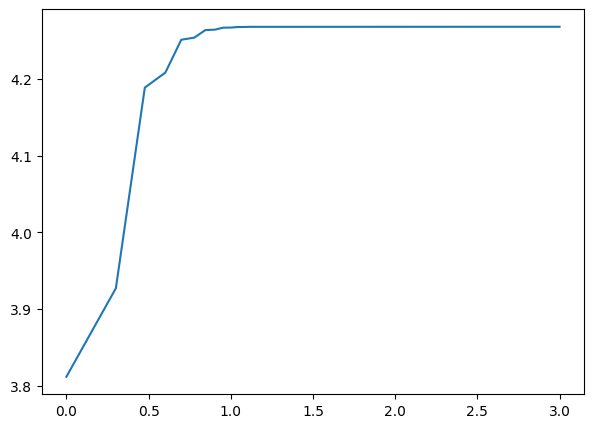

In [81]:
# Custom tick formatter that prints 10^x
def log_tick_formatter(val, pos=None):
    return r"$10^{%.0f}$" % val

for alpha, beta in alpha_beta_list:
    plt.figure(figsize=(7,5))

    for lam in lambdas:
        norms = gradient_descent_full_trace(X_train, y_train, lam, s, alpha, beta, max_iter=max_iter)
        iters = np.arange(1, len(norms)+1)

        # Plot log10(iterations)
        plt.plot(np.log10(iters), norms, label=f"lambda={lam}")

    plt.xlabel("Iteration (log scale as $10^x$)")
    plt.ylabel("||w_k||₂")
    plt.title(f"Norm evolution for different λ values\n(alpha={alpha}, beta={beta})")
    plt.legend()
    plt.grid(True)

    # Use ticks that display 10^0, 10^1, ..., 10^x
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # integer ticks: 0,1,2,...
    ax.xaxis.set_major_formatter(log_tick_formatter)

    plt.show()

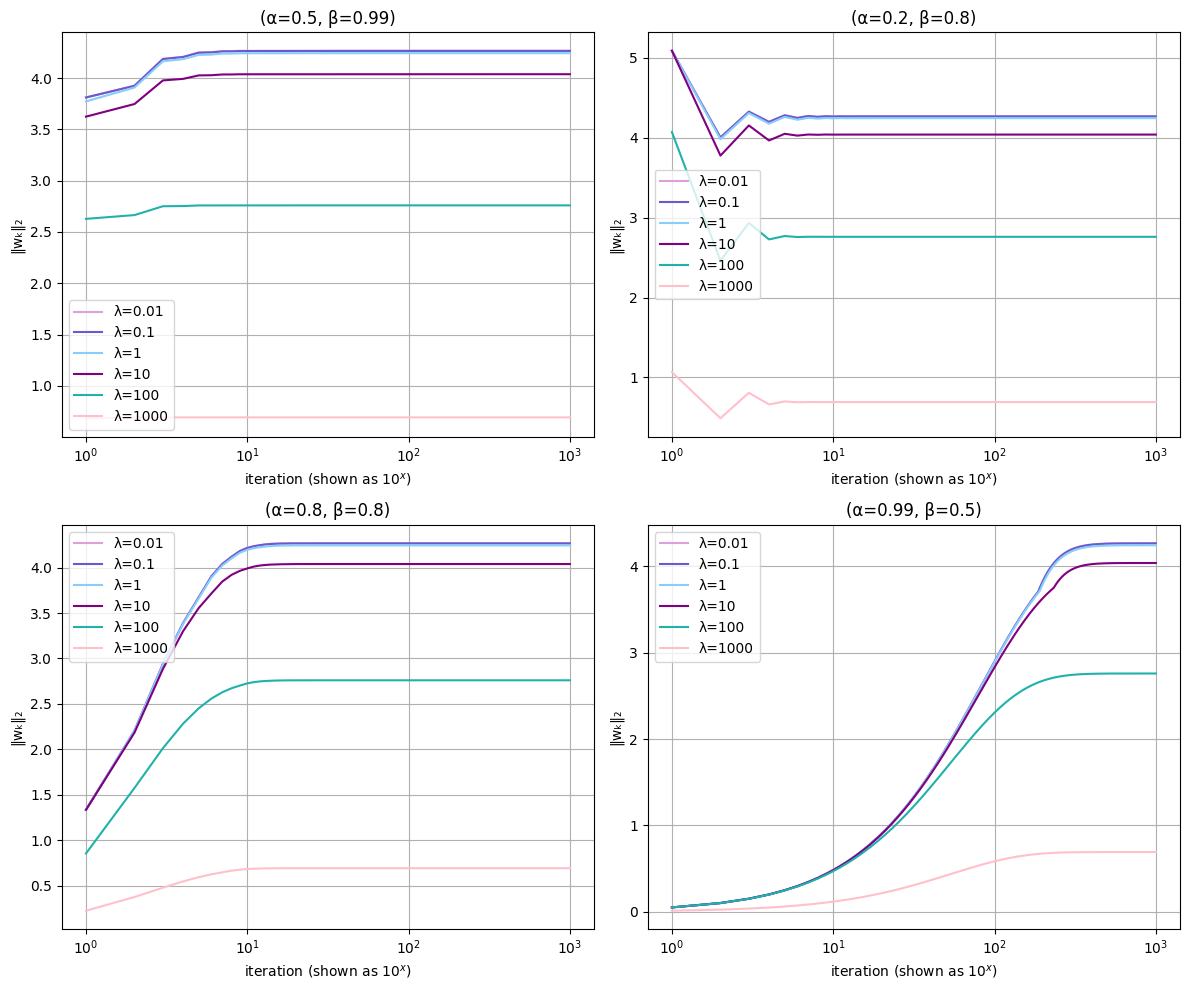

In [ ]:
# ---- tick formatter ----
def log_tick_formatter(val, pos=None):
    return r"$10^{%.0f}$" % val

# ---- choose 4 (alpha, beta) pairs ----
alpha_beta_list = [
    (0.5, 0.9),
    (0.2, 0.8),
    (0.8, 0.8),
    (0.99, 0.5),
]

lambdas = [0.01, 0.1, 1, 10, 100, 1000]
s = 1.0
max_iter = 1000

# ---- create a 2×2 figure ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()   

colors = ["plum", "slateblue", "lightskyblue", "purple", "lightseagreen", "pink"]   

for i, (alpha, beta) in enumerate(alpha_beta_list):
    ax = axes[i]
    
    for j, lam in enumerate(lambdas):
        norms = gradient_descent_full_trace(X_train, y_train, lam, s, alpha, beta, max_iter=max_iter)
        iters = np.arange(1, len(norms) + 1)

        if colors is None:
            ax.plot(np.log10(iters), norms, label=f"λ={lam}")
        else:
            ax.plot(np.log10(iters), norms, color=colors[j], label=f"λ={lam}")

    ax.set_title(f"(α={alpha}, β={beta})")
    ax.set_xlabel("iteration (shown as $10^x$)")
    ax.set_ylabel("‖wₖ‖₂")
    ax.grid(True)

    # Format ticks as 10^x
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(log_tick_formatter)

    ax.legend()

plt.tight_layout()
plt.show()

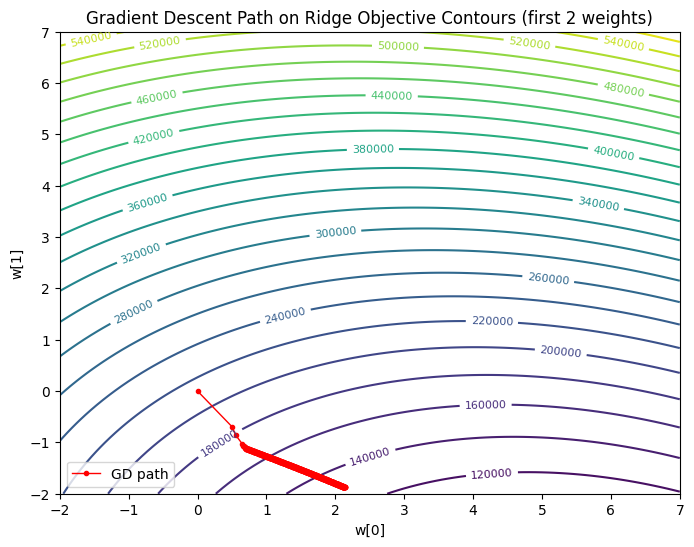

In [82]:
# --- Using your existing data generation ---
np.random.seed(2025)
n, p, k = 500, 50, 8
sigma = 1.0

m = 10
Z = np.random.randn(n, m)
A = np.random.randn(m, p) * 0.8
X = Z.dot(A) + 0.1 * np.random.randn(n, p)

w_true = np.zeros(p)
w_true[:k] = np.linspace(5.0, 1.0, k) * np.random.choice([1, -1], k)
y = X.dot(w_true) + sigma * np.random.randn(n)

idx = np.random.permutation(n)
train_idx, test_idx = idx[:350], idx[350:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# --- Functions ---
def ridge_objective(X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)

def ridge_grad(X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent(X, y, lam, s, alpha, beta):
    w = np.zeros(X.shape[1])
    trajectory = [w.copy()]
    
    for _ in range(1000):
        grad = ridge_grad(X, y, w, lam)
        t = s
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta
        w = w - t * grad
        trajectory.append(w.copy())
    return w, trajectory

# --- Run gradient descent ---
lam = 1.0
s = 1e-4
alpha = 0.5
beta = 0.5
w_opt, trajectory = gradient_descent(X_train, y_train, lam, s, alpha, beta)

trajectory = np.array(trajectory)

# --- Plot contour for first two weights ---
w0_vals = np.linspace(-2, 7, 100)
w1_vals = np.linspace(-2, 7, 100)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
OBJ = np.zeros_like(W0)

# Fix other weights to zero for visualization
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w_vis = np.zeros(p)
        w_vis[0] = W0[i, j]
        w_vis[1] = W1[i, j]
        OBJ[i, j] = ridge_objective(X_train, y_train, w_vis, lam)

plt.figure(figsize=(8,6))
# Contour lines
cs = plt.contour(W0, W1, OBJ, levels=30, cmap='viridis')
plt.clabel(cs, inline=1, fontsize=8)

# Gradient descent path
plt.plot(trajectory[:,0], trajectory[:,1], 'ro-', markersize=3, linewidth=1, label='GD path')

plt.xlabel('w[0]')
plt.ylabel('w[1]')
plt.title('Gradient Descent Path on Ridge Objective Contours (first 2 weights)')
plt.legend()
plt.show()